In [1]:
from datetime import datetime
import numpy as np

from IPython.display import Image, display
import ROOT

In [31]:
# Intialise the files
filenameslist = ['./hists/hist_3cm.root', './hists/hist_30cm.root', './hists/hist_1m.root', './hists/hist_3m.root']
open_infiles = [ROOT.TFile.Open(filename) for filename in filenameslist]

def plotmc(var, binedges, logy=False, logx=False):
    # Create a canvas
    now_str = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    binedges = np.array(binedges, dtype=np.float64)

    c = ROOT.TCanvas("c"+now_str, "c"+now_str, 800, 600)
    ROOT.gStyle.SetOptStat(0)
    if logy:
        c.SetLogy()
    if logx:
        c.SetLogx()
    legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

    varhists = [file.Get(var) for file in open_infiles]

    for i, hist in enumerate(varhists):
        newhist = hist.Rebin(len(binedges)-1, var+'_rebinned', binedges)

        newhist.SetLineColor(i+2)
        newhist.SetLineWidth(2)

        newhist.Draw("HIST SAME E1")

        legend.AddEntry(newhist, filenameslist[i], "l")

    legend.Draw()
    c.Update()

    plotname = f"plots/{var}_{now_str}.png"
    c.SaveAs(plotname)
    return plotname       

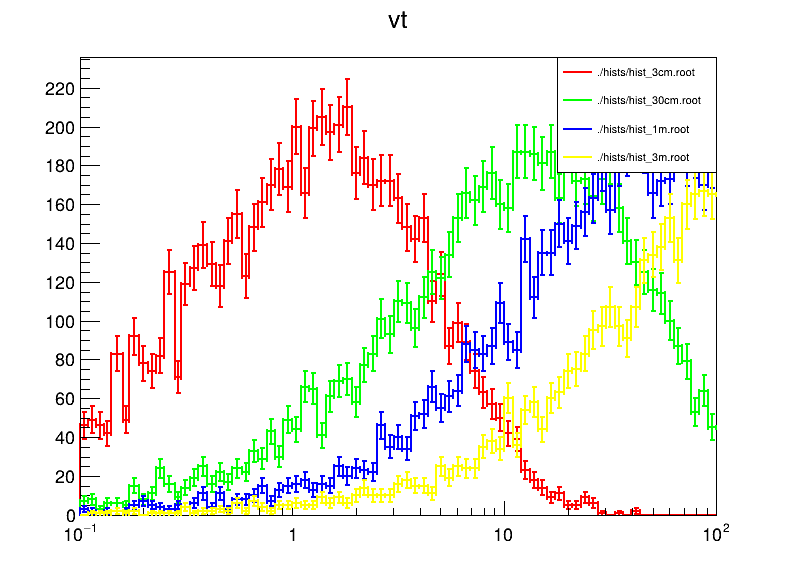

Info in <TCanvas::Print>: png file plots/vt_e_2025_04_22_16_08_28.png has been created


In [32]:
vte = plotmc('vt_e', np.round(10**np.arange(-1, 2.04, 0.04), 2), False, True)
display(Image(filename=vte))

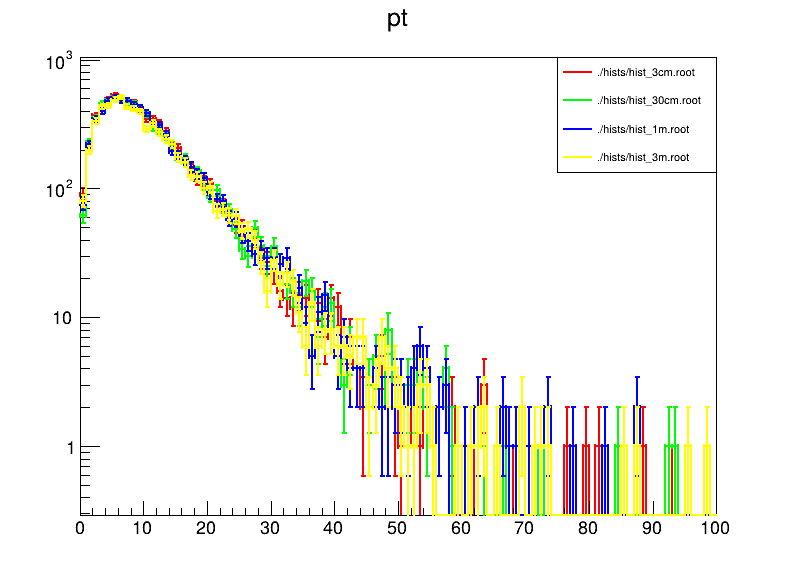

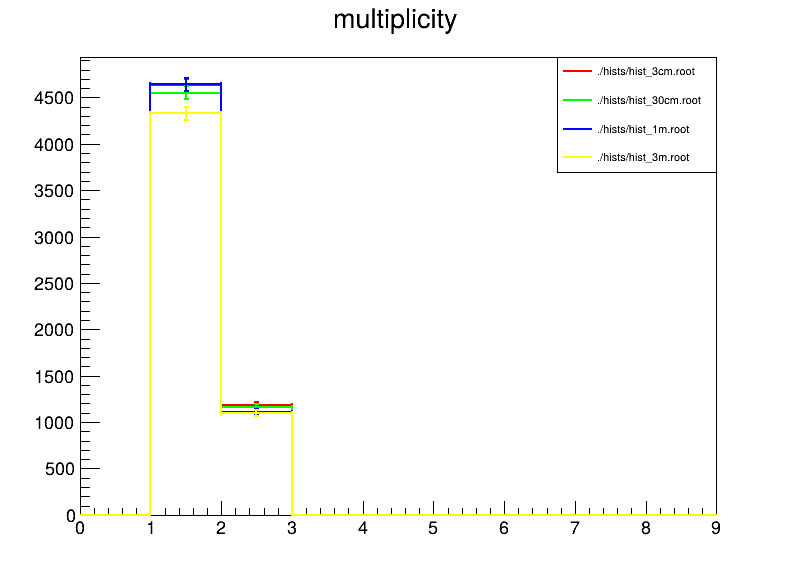

Info in <TCanvas::Print>: png file plots/pt_e_2025_04_22_16_08_28.png has been created
Info in <TCanvas::Print>: png file plots/n_e_2025_04_22_16_08_28.png has been created


In [33]:
pte = plotmc('pt_e', np.arange(0, 101, 1), True)
ne = plotmc('n_e', np.arange(0, 10, 1), False, False)
display(Image(filename=pte), Image(filename=ne))

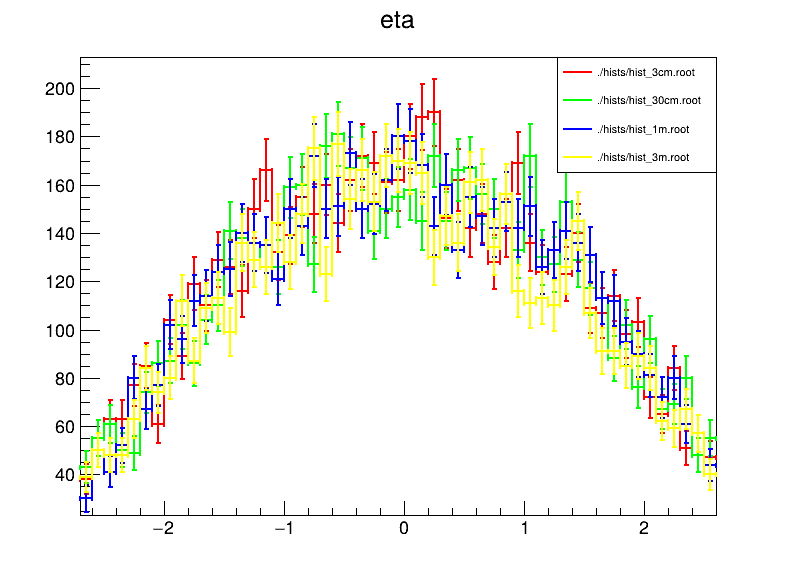

Info in <TCanvas::Print>: png file plots/eta_e_2025_04_22_16_08_29.png has been created


In [34]:
pname = plotmc('eta_e', np.arange(-2.7, 2.7, 0.1), False, False)
display(Image(filename=pname))

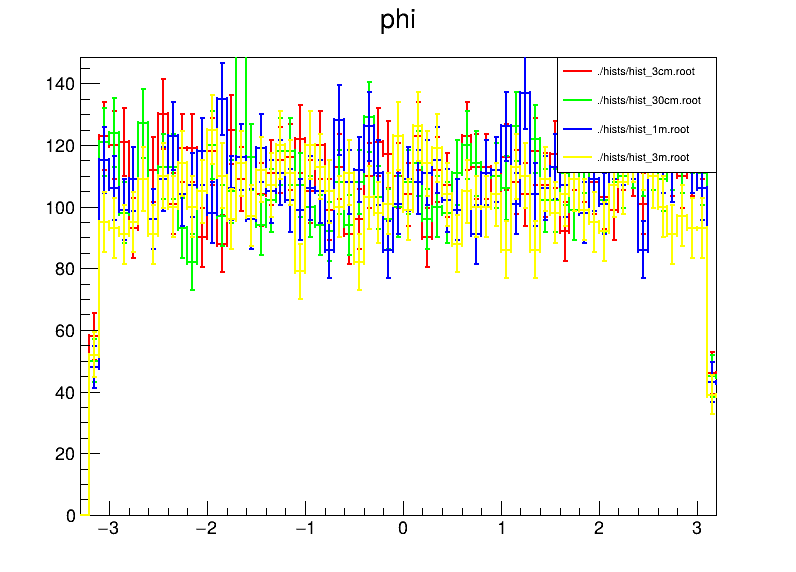

Info in <TCanvas::Print>: png file plots/phi_e_2025_04_22_16_08_29.png has been created


In [35]:
pname = plotmc('phi_e', np.arange(-3.3, 3.3, 0.1), False, False)
display(Image(filename=pname))

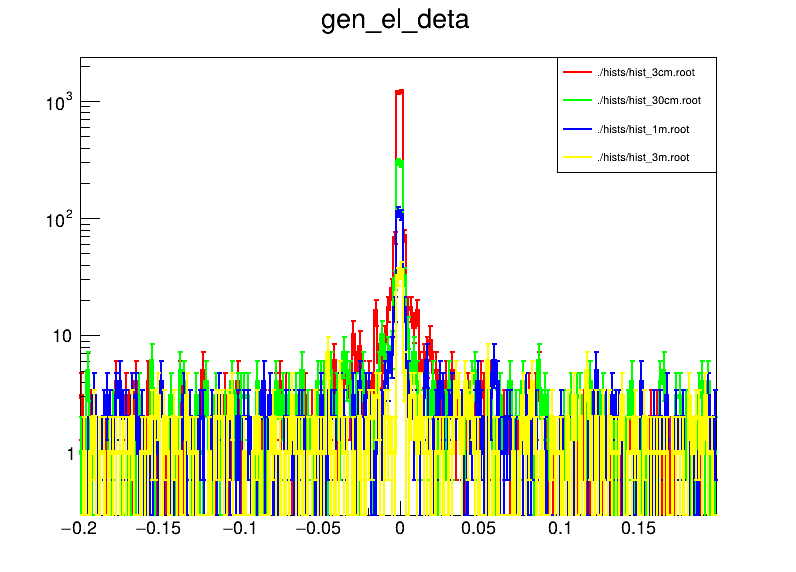

Info in <TCanvas::Print>: png file plots/gen_el_deta_2025_04_22_16_08_42.png has been created


In [37]:
pname = plotmc('gen_el_deta', np.arange(-0.2, 0.2, 0.002), True, False)
display(Image(filename=pname))

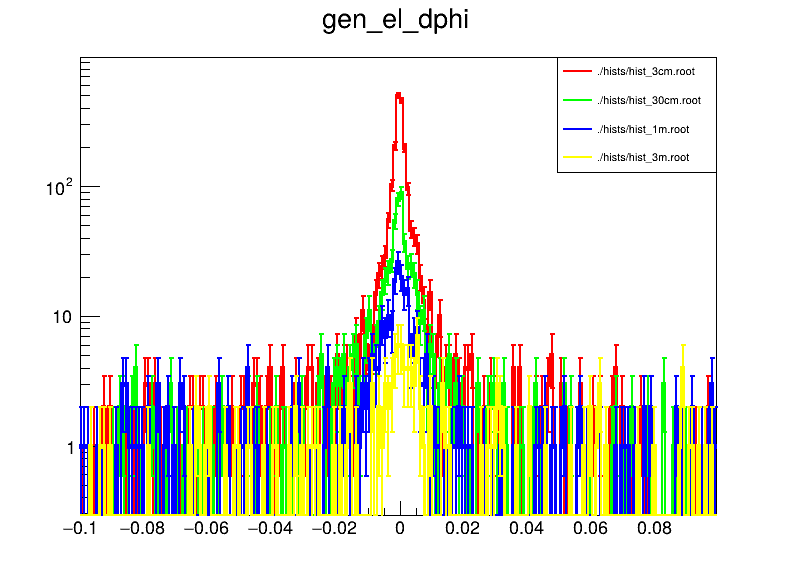

Info in <TCanvas::Print>: png file plots/gen_el_dphi_2025_04_22_16_09_20.png has been created


In [39]:
pname = plotmc('gen_el_dphi', np.arange(-0.1, 0.1, 0.001), True, False)
display(Image(filename=pname))

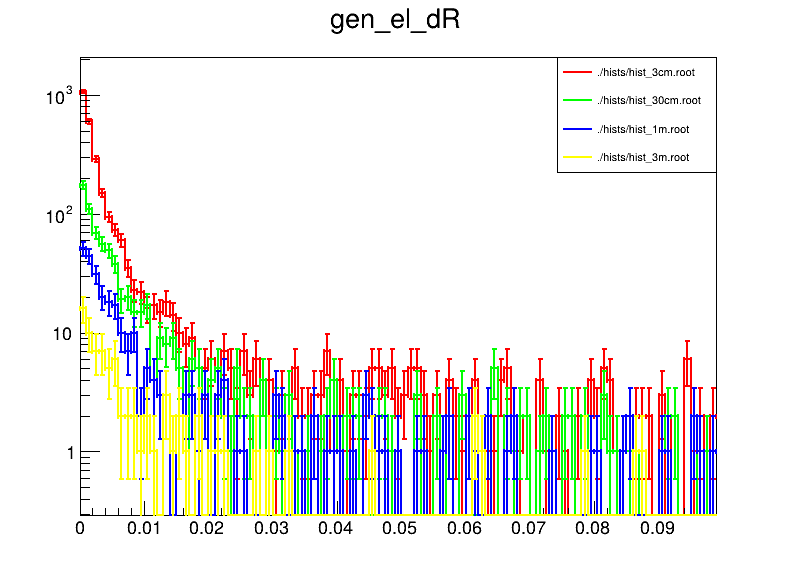

Info in <TCanvas::Print>: png file plots/gen_el_dR_2025_04_22_16_10_09.png has been created


In [41]:
pname = plotmc('gen_el_dR', np.arange(0, 0.1, 0.001), True, False)
display(Image(filename=pname))